# Study 01 — How often should a penalty shootout reach sudden death?

## Question

How often should a penalty shootout still be level after five penalties each and therefore reach sudden death?

We will start with the simplest credible model:

- equal teams;
- every penalty is independent;
- every penalty has the same probability of being scored;
- no player, goalkeeper, pressure, order or score-state effects.

The first task is to build and understand that baseline model before adding anything else.

## Simulating one penalty

We begin with the smallest possible unit of the shootout: a single penalty kick.

For the baseline model, every penalty has the same probability of being scored. We will start with a scoring probability of **72.5%**, because this is the benchmark used in Joe Buchdahl's example and gives us a result we can later validate against.

To simulate a kick, we generate a random number between 0 and 1. If that number is below 0.725, we count the penalty as scored; otherwise, it is missed.

We also use a fixed random seed so that the notebook is reproducible: rerunning it will generate the same sequence of simulated outcomes.

In [1]:
import numpy as np

# Create a reproducible random-number generator.
rng = np.random.default_rng(42)

# Probability that a penalty is scored.
p_score = 0.725

# Simulate one penalty: True = goal, False = miss.
penalty = rng.random() < p_score

penalty

False

## Simulating five penalties for one team

A team can take up to five penalties in the initial phase of a shootout.

Under our baseline assumptions, each of those penalties is independent and has the same 72.5% chance of being scored.

We can therefore simulate five kicks at once and count how many are scored.

In [2]:
# Simulate five penalties for one team.
team_penalties = rng.random(5) < p_score

# Count the number of goals.
team_score = team_penalties.sum()

team_penalties, team_score

(array([ True, False,  True,  True, False]), np.int64(3))

## Simulating one complete shootout

We now simulate five penalties for each team.

The two teams are treated identically: every kick is independent and every kick has the same 72.5% scoring probability.

For our current question, we do not yet need to model what happens during sudden death itself. We only need to know whether the teams are level after five kicks each.

If the two five-kick scores are equal, the shootout has reached sudden death.

In [3]:
# Simulate five penalties for each team.
team_a_penalties = rng.random(5) < p_score
team_b_penalties = rng.random(5) < p_score

# Count each team's goals.
team_a_score = team_a_penalties.sum()
team_b_score = team_b_penalties.sum()

# Sudden death is reached if the scores are level after five kicks each.
reaches_sudden_death = team_a_score == team_b_score

team_a_penalties, team_a_score, team_b_penalties, team_b_score, reaches_sudden_death

(array([False, False,  True,  True,  True]),
 np.int64(3),
 array([False,  True, False,  True,  True]),
 np.int64(3),
 np.True_)

## Turning the shootout into a reusable simulation

We now have the logic for one shootout.

To estimate how often sudden death occurs, we need to repeat the same process many times. Rather than rewriting the same code repeatedly, we will put the one-shootout logic into a function.

The function will return `True` when the two teams are level after five penalties each, and `False` otherwise.

In [4]:
def simulate_shootout(rng, p_score):
    # Simulate five penalties for each team.
    team_a_penalties = rng.random(5) < p_score
    team_b_penalties = rng.random(5) < p_score

    # Count each team's goals.
    team_a_score = team_a_penalties.sum()
    team_b_score = team_b_penalties.sum()

    # Return whether the shootout reaches sudden death.
    return team_a_score == team_b_score

In [5]:
simulate_shootout(rng, p_score)

np.False_

`np.False_` is NumPy's version of the Boolean value `False`.

The function compares the two teams' scores using NumPy values, so NumPy returns its own Boolean type rather than Python's built-in `False`.

For our purposes, the meaning is simply:

**This simulated shootout did not reach sudden death.**

## Repeating the simulation many times

A single simulated shootout can only produce one of two outcomes:

- it reaches sudden death;
- it does not reach sudden death.

That tells us what happened in that one simulation, but not how likely sudden death is in general.

To estimate the probability, we repeat exactly the same simulated shootout **10,000 times**.

For each simulated shootout, the function returns:

- `True` if the teams are level after five penalties each;
- `False` if they are not.

We store all 10,000 of those results in a list.

When NumPy calculates the mean of Boolean values, it treats:

- `True` as `1`;
- `False` as `0`.

So if 2,771 of 10,000 shootouts reach sudden death, the mean is:

\[
\frac{2771}{10000} = 0.2771
\]

which is the same as **27.71%**.

This proportion is our Monte Carlo estimate of the probability that a shootout reaches sudden death under our current assumptions.

In [6]:
# Number of simulated shootouts.
n_simulations = 10_000

# Simulate each shootout and record whether it reaches sudden death.
results = [
    simulate_shootout(rng, p_score)
    for _ in range(n_simulations)
]

# Estimate the probability of reaching sudden death.
estimated_probability = np.mean(results)

estimated_probability

np.float64(0.2771)

The simulation estimated that **27.71%** of shootouts reached sudden death.

This is only a Monte Carlo estimate, so we should not expect it to match the benchmark exactly with just 10,000 simulations. The result will move around slightly because of random sampling.

The important point is that it is already close to the stated benchmark of **27.987%**.

Next we will increase the number of simulations and see whether the estimate settles closer to that value.

## Does the estimate stabilise?

Our first estimate used 10,000 simulated shootouts and produced a sudden-death rate of **27.71%**.

Because Monte Carlo simulation relies on random sampling, the estimate will contain some sampling noise. With more simulations, that noise should become smaller and the estimate should settle around the underlying probability.

We will repeat the experiment with progressively larger samples:

- 10,000 shootouts;
- 100,000 shootouts;
- 1,000,000 shootouts.

For each sample size we start the random-number generator from the same fixed seed. This keeps the experiment reproducible.

In [7]:
# Sample sizes to test.
sample_sizes = [10_000, 100_000, 1_000_000]

estimates = []

for n_simulations in sample_sizes:
    # Reset the random-number generator for reproducibility.
    test_rng = np.random.default_rng(42)

    # Simulate the requested number of shootouts.
    results = [
        simulate_shootout(test_rng, p_score)
        for _ in range(n_simulations)
    ]

    # Store the estimated sudden-death probability.
    estimates.append(np.mean(results))

list(zip(sample_sizes, estimates))

[(10000, np.float64(0.2768)),
 (100000, np.float64(0.28047)),
 (1000000, np.float64(0.2803))]

The estimates move around as the sample size changes:

- **10,000 simulations:** 27.68%
- **100,000 simulations:** 28.047%
- **1,000,000 simulations:** 28.030%

The larger simulations are much closer to one another than the smaller run, which is what we would expect if the estimate is settling around a stable underlying probability.

The 1,000,000-shootout estimate of **28.03%** is also very close to the stated benchmark of **27.987%**.

The remaining difference is small enough that it could simply be Monte Carlo sampling noise. The next step is to calculate the exact probability independently, so we can check the simulation against something that does not depend on random sampling.

## Calculating the exact probability

The simulation suggests that the true probability is close to 28%, but simulation will always contain some random sampling noise.

For this simple baseline model, we can also calculate the probability exactly.

Each team takes five penalties, with every penalty having the same 72.5% chance of being scored.

So a team can finish the five kicks with:

- 0 goals;
- 1 goal;
- 2 goals;
- 3 goals;
- 4 goals;
- 5 goals.

Sudden death is reached whenever the two teams finish with the **same score**.

That means we need to calculate:

$$
P(0\text{-}0) + P(1\text{-}1) + P(2\text{-}2) + P(3\text{-}3) + P(4\text{-}4) + P(5\text{-}5)
$$

Because the teams are independent and have the same scoring probability, for any score \(k\):

$$
P(k\text{-}k) = P(\text{Team A scores } k)^2
$$


The number of goals scored from five independent penalties follows a **binomial distribution**.

We can therefore calculate the probability of each possible five-kick score and then add the probabilities of all six possible ties.

In [8]:
from math import comb

# Calculate the probability of scoring exactly k goals from five penalties.
score_probabilities = []

for k in range(6):
    probability = (
        comb(5, k)
        * p_score**k
        * (1 - p_score)**(5 - k)
    )

    score_probabilities.append(probability)

# Display each possible score and its probability.
for k, probability in enumerate(score_probabilities):
    print(f"{k} goals: {probability:.3%}")

0 goals: 0.157%
1 goals: 2.073%
2 goals: 10.931%
3 goals: 28.819%
4 goals: 37.989%
5 goals: 20.030%


The most likely five-kick score for a team with a 72.5% conversion probability is **4 goals**, which occurs about **37.99%** of the time.

A team scores:

- 3 goals about 28.82% of the time;
- 4 goals about 37.99% of the time;
- 5 goals about 20.03% of the time.

Together, those three outcomes account for almost all five-kick sequences.

To reach sudden death, however, it is not enough for either team to have a likely score. **Both teams must finish on the same score.**

For example, a 4–4 result requires Team A to score exactly four and Team B independently to score exactly four.

Because the teams are independent:

$$
P(4\text{-}4) = P(4)^2
$$

We can calculate this for every possible tied score from 0–0 through 5–5 and then add them together.

In [9]:
# Calculate the probability of each possible tied score.
tie_probabilities = [
    probability**2
    for probability in score_probabilities
]

# Display each tied score and its probability.
for score, probability in enumerate(tie_probabilities):
    print(f"{score}-{score}: {probability:.3%}")

0-0: 0.000%
1-1: 0.043%
2-2: 1.195%
3-3: 8.305%
4-4: 14.431%
5-5: 4.012%


The tied scores are not equally important.

At a 72.5% penalty conversion rate:

- **4–4** alone occurs about **14.43%** of the time;
- **3–3** contributes another **8.31%**;
- **5–5** contributes about **4.01%**;
- ties at 0–0, 1–1 and 2–2 are comparatively rare.

So most shootouts that reach sudden death do so because **both teams score three or four of their five penalties**.

We can now add all six tied-score probabilities together to get the exact overall probability of reaching sudden death.

In [10]:
# Add the probabilities of every possible tied score.
exact_probability = sum(tie_probabilities)

print(f"Exact probability: {exact_probability:.6%}")

Exact probability: 27.987151%


The exact calculation gives:

**27.987151%**

Rounded to three decimal places, that is **27.987%**, exactly matching the benchmark stated in Joe Buchdahl's example.

That gives us two independent checks on the baseline model:

- the Monte Carlo simulation converged to about 28%;
- the exact binomial calculation gives 27.987151%.

So the simulation logic is behaving as intended.

We can now move on to the actual research question: **how does the chance of reaching sudden death change when the penalty conversion probability changes?**

## Changing the penalty conversion probability

So far we have fixed the scoring probability at 72.5%.

We now want to know whether reaching sudden death becomes more or less likely as penalties become easier to score.

To keep the first study small, we will vary only one assumption: the probability that any penalty is scored.

Everything else remains unchanged:

- both teams have the same scoring probability;
- all penalties are independent;
- each team has five initial kicks;
- sudden death is reached when the five-kick totals are equal.

We will examine conversion probabilities from **50% to 95%**, in steps of five percentage points.

Rather than running a large simulation at every value, we can use the exact calculation we have just validated. This lets us see the underlying relationship without Monte Carlo noise.

## Changing the penalty conversion probability

So far we have fixed the scoring probability at 72.5%.

We now want to know whether reaching sudden death becomes more or less likely as penalties become easier to score.

To keep the first study small, we will vary only one assumption: the probability that any penalty is scored.

Everything else remains unchanged:

- both teams have the same scoring probability;
- all penalties are independent;
- each team has five initial kicks;
- sudden death is reached when the five-kick totals are equal.

We will examine conversion probabilities from **50% to 95%**, in steps of five percentage points.

Rather than running a large simulation at every value, we can use the exact calculation we have just validated. This lets us see the underlying relationship without Monte Carlo noise.

In [11]:
def exact_sudden_death_probability(p_score):
    # Calculate the probability of each possible five-kick score.
    score_probabilities = []

    for k in range(6):
        probability = (
            comb(5, k)
            * p_score**k
            * (1 - p_score)**(5 - k)
        )

        score_probabilities.append(probability)

    # Add the probabilities of all tied scores.
    return sum(
        probability**2
        for probability in score_probabilities
    )

In [12]:
exact_sudden_death_probability(0.725)

0.27987150509310266

## Sudden death across different conversion probabilities

We can now apply the exact calculation to a range of scoring probabilities.

The aim is not to search every possible value. We only need enough points to reveal the shape of the relationship.

We will therefore check scoring probabilities from **50% to 95%**, in five-percentage-point steps.

In [13]:
# Penalty conversion probabilities to examine.
conversion_probabilities = np.arange(0.50, 0.951, 0.05)

# Calculate the exact sudden-death probability at each value.
sudden_death_probabilities = [
    exact_sudden_death_probability(p)
    for p in conversion_probabilities
]

# Display the results.
for p_score, p_sudden_death in zip(
    conversion_probabilities,
    sudden_death_probabilities
):
    print(
        f"{p_score:.0%} conversion: "
        f"{p_sudden_death:.3%} reach sudden death"
    )

50% conversion: 24.609% reach sudden death
55% conversion: 24.747% reach sudden death
60% conversion: 25.176% reach sudden death
65% conversion: 25.944% reach sudden death
70% conversion: 27.156% reach sudden death
75% conversion: 29.020% reach sudden death
80% conversion: 31.975% reach sudden death
85% conversion: 36.984% reach sudden death
90% conversion: 46.168% reach sudden death
95% conversion: 64.066% reach sudden death


### What changes as penalties become easier to score?

The relationship is clear: **once the scoring probability is above 50%, increasing the conversion rate makes sudden death more likely.**

At first that may seem slightly counter-intuitive. Better penalty taking might sound as though it should help separate the teams more quickly.

But both teams are improving at exactly the same rate.

When scoring is relatively difficult, their five-kick totals are spread across several possible scores. As scoring becomes easier, both teams increasingly cluster around the same high totals — particularly 4 and 5 goals.

That makes matching scores more common.

For example:

- at 50% conversion, about **24.61%** of shootouts reach sudden death;
- at 70%, this rises to **27.16%**;
- at 80%, it is almost **31.98%**;
- at 90%, it reaches **46.17%**;
- at 95%, almost **64.07%** reach sudden death.

The effect is fairly modest through the middle of the range, but becomes much stronger once penalty conversion becomes very high.

At the extreme, the intuition becomes obvious: if penalties were scored **100% of the time**, both teams would always finish 5–5 and **every shootout would reach sudden death**.

## Visualising the relationship

A table gives us the individual probabilities, but a graph makes the shape of the relationship much easier to see.

We will plot penalty conversion probability on the horizontal axis and the exact probability of reaching sudden death on the vertical axis.

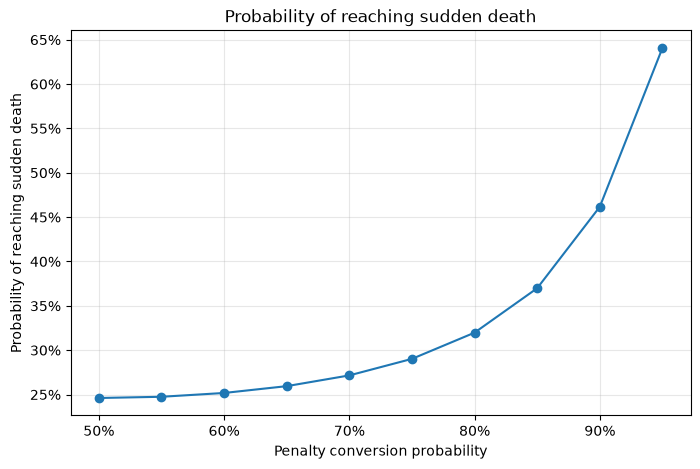

In [14]:
import matplotlib.pyplot as plt

# Plot conversion probability against sudden-death probability.
plt.figure(figsize=(8, 5))

plt.plot(
    conversion_probabilities,
    sudden_death_probabilities,
    marker="o"
)

# Label the chart.
plt.title("Probability of reaching sudden death")
plt.xlabel("Penalty conversion probability")
plt.ylabel("Probability of reaching sudden death")

# Format both axes as percentages.
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.grid(alpha=0.3)
plt.show()

### Interpreting the curve

The graph makes the shape of the relationship clearer.

From 50% through roughly 75% conversion, the probability of reaching sudden death rises only gradually.

Above about 80%, however, the curve begins to steepen. As penalties become very easy to score, both teams increasingly finish with the same high total — especially 5–5 — so sudden death becomes much more common.

This is therefore not a linear relationship. Improving conversion from 55% to 60% has only a small effect, while improving from 90% to 95% has a very large one.

## Which tied scores cause sudden death?

At the 72.5% benchmark, we already saw that some tied scores are much more common than others.

A bar chart lets us see how much each possible scoreline contributes to the overall 27.987% probability of reaching sudden death.

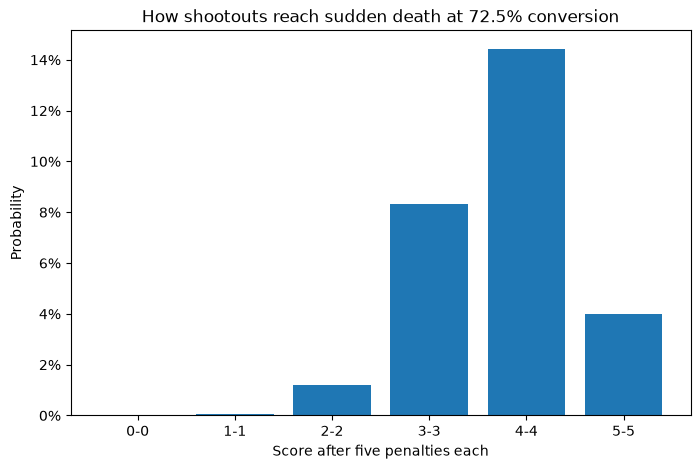

In [15]:
# Labels for each possible tied score.
tie_scores = [f"{score}-{score}" for score in range(6)]

# Plot the probability of each tied score.
plt.figure(figsize=(8, 5))

plt.bar(
    tie_scores,
    tie_probabilities
)

# Label the chart.
plt.title("How shootouts reach sudden death at 72.5% conversion")
plt.xlabel("Score after five penalties each")
plt.ylabel("Probability")

# Format the vertical axis as percentages.
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

### Where does the 27.987% come from?

At a 72.5% conversion probability, sudden death is overwhelmingly driven by a small number of tied scores.

The largest contribution is **4–4**, which occurs about **14.43% of all shootouts**. That single scoreline accounts for more than half of the total probability of reaching sudden death.

The next most important outcomes are:

- **3–3:** 8.31% of all shootouts;
- **5–5:** 4.01%;
- **2–2:** 1.20%.

Ties at 0–0 and 1–1 are effectively negligible.

This helps explain why higher conversion probabilities eventually make sudden death much more common. As scoring becomes easier, both teams become increasingly concentrated around the same high five-kick totals.

## Composition of sudden-death shootouts

The previous chart shows how often each tied score occurs among all shootouts.

We can look at the same result another way: **conditional on a shootout reaching sudden death, which tied score did it reach?**

To calculate this, we divide the probability of each tied score by the overall sudden-death probability.

In [16]:
# Calculate each tied score's share of all sudden-death shootouts.
sudden_death_shares = [
    probability / exact_probability
    for probability in tie_probabilities
]

# Display the result.
for score, share in enumerate(sudden_death_shares):
    print(f"{score}-{score}: {share:.2%} of sudden-death shootouts")
    

0-0: 0.00% of sudden-death shootouts
1-1: 0.15% of sudden-death shootouts
2-2: 4.27% of sudden-death shootouts
3-3: 29.68% of sudden-death shootouts
4-4: 51.56% of sudden-death shootouts
5-5: 14.34% of sudden-death shootouts


### Most sudden-death shootouts arrive at 4–4

At a 72.5% conversion probability, **more than half of all shootouts that reach sudden death do so at 4–4**.

Among sudden-death shootouts:

- **51.56%** are tied 4–4;
- **29.68%** are tied 3–3;
- **14.34%** are tied 5–5;
- only **4.42%** arrive via 0–0, 1–1 or 2–2 combined.

So roughly **four out of five sudden-death shootouts are either 3–3 or 4–4 after five penalties each**.

This gives us a clearer explanation for the overall 27.987% result. Under the baseline model, sudden death is not produced evenly across all possible scores: it is mostly the consequence of both teams independently landing on the same highly probable score.

## Study conclusion

Under the baseline model, a penalty shootout with a **72.5% scoring probability for every kick** reaches sudden death **27.987% of the time** — a little more than one shootout in four.

The Monte Carlo simulation produced estimates close to this figure, and the independent exact calculation reproduced the stated 27.987% benchmark.

The more interesting result came from changing the scoring probability.

Across the 50%–95% range examined, **higher penalty conversion makes sudden death increasingly likely**:

* 50% conversion → 24.609%
* 70% conversion → 27.156%
* 80% conversion → 31.975%
* 90% conversion → 46.168%
* 95% conversion → 64.066%

The effect is initially modest but becomes much stronger at very high conversion rates. This happens because both teams' five-kick totals become increasingly concentrated on the same high scores.

At the 72.5% benchmark, **4–4 is the dominant route into sudden death**. It accounts for 51.56% of all sudden-death shootouts. Another 29.68% arrive at 3–3, meaning roughly four out of five sudden-death shootouts in this model are tied either 3–3 or 4–4.

### Limitations

This is deliberately a baseline model rather than a model of real-world penalty taking.

It assumes:

* both teams are equally good at penalties;
* every penalty has the same scoring probability;
* kicks are independent;
* individual kicker and goalkeeper ability does not matter;
* scoring probability does not change with pressure, score state or kick order.

We have also not used real penalty-shootout data. The purpose of this first study was to establish and validate the simplest credible model before deciding whether greater complexity is justified.

### Scope decision

The original question has been answered, so the study stops here.

Possible extensions — unequal teams, individual kickers, pressure effects, taking order, empirical conversion rates and the length of sudden death — should be treated as separate sporting questions rather than added automatically to this model.
